<a href="https://colab.research.google.com/github/Nathlima1700/Analise-salarial-de-profissionais-de-dados/blob/main/C%C3%B3pia_de_Desafio_Regress%C3%A3o_Aplicada_%C3%A0_Engenharia_de_Materiais.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

# ETAPA 1 — ANÁLISE EXPLORATÓRIA DE DADOS

# 1. Importar as bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

sns.set(style='whitegrid')

In [ ]:
# Importar bibliotecas
import pandas as pd
from google.colab import files

# Fazer upload direto do seu computador
print("📁 Selecione o arquivo CSV com os dados do concreto (ex: em Downloads):")
uploaded = files.upload()

📁 Selecione o arquivo CSV com os dados do concreto (ex: em Downloads):


Saving dados_concreto_-_Sheet1.csv to dados_concreto_-_Sheet1.csv


In [ ]:
# Pegar o nome do arquivo automaticamente
nome_arquivo = list(uploaded.keys())[0]

# Ler o CSV e exibir informações iniciais
df = pd.read_csv(nome_arquivo)
print("\n✅ Arquivo carregado com sucesso!")
print("Dimensões do DataFrame:", df.shape)
print("\nColunas disponíveis:")
print(df.columns.tolist())

# Mostrar as 5 primeiras linhas
df.head()


✅ Arquivo carregado com sucesso!
Dimensões do DataFrame: (2029, 10)

Colunas disponíveis:
['Cement', 'Blast Furnace Slag', 'Fly Ash', 'Water', 'Superplasticizer', 'Coarse Aggregate', 'Fine Aggregate', 'Age', 'Concrete compressive strength', 'Strength Category']


,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Concrete compressive strength,Strength Category
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28.0,79.99,Alto
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28.0,61.89,Alto
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270.0,40.27,Baixa
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365.0,41.05,Baixa
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360.0,44.30,Baixa


In [ ]:
# 5. Informações gerais
print("\nInformações do dataset:")
df.info()


Informações do dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2029 entries, 0 to 2028
Data columns (total 10 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Cement                         2029 non-null   float64
 1   Blast Furnace Slag             2029 non-null   float64
 2   Fly Ash                        2029 non-null   float64
 3   Water                          2029 non-null   float64
 4   Superplasticizer               2029 non-null   float64
 5   Coarse Aggregate               2029 non-null   float64
 6   Fine Aggregate                 2029 non-null   float64
 7   Age                            2029 non-null   float64
 8   Concrete compressive strength  2020 non-null   float64
 9   Strength Category              2029 non-null   object 
dtypes: float64(9), object(1)
memory usage: 158.6+ KB


In [ ]:
# 6. Estatísticas descritivas
print("\nEstatísticas descritivas:")
display(df.describe())


Estatísticas descritivas:


,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Concrete compressive strength
count,2029.000000,2029.000000,2029.000000,2029.000000,2029.000000,2029.000000,2029.000000,2029.000000,2020.000000
mean,415.147610,107.776688,78.604091,264.240315,9.045293,1444.538492,1139.313258,67.255643,35.886683
std,237.133806,145.230234,106.149019,111.056771,10.239884,604.194394,481.913282,103.260526,16.860121
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.100000
25%,250.000000,0.000000,0.000000,182.000000,0.000000,967.100000,776.400000,14.000000,23.500000
50%,350.400000,26.000000,0.000000,206.000000,7.800000,1104.000000,889.000000,28.000000,34.675000
75%,512.400000,187.000000,136.200000,345.800000,13.600000,1911.800000,1502.800000,75.600000,46.230000
max,1487.600000,923.700000,500.900000,639.900000,83.700000,3150.000000,2779.300000,1022.000000,87.200000


In [ ]:
 #7. Verificar valores nulos
print("\nValores nulos por coluna:")
print(df.isnull().sum())


Valores nulos por coluna:
Cement                           0
Blast Furnace Slag               0
Fly Ash                          0
Water                            0
Superplasticizer                 0
Coarse Aggregate                 0
Fine Aggregate                   0
Age                              0
Concrete compressive strength    9
Strength Category                0
dtype: int64


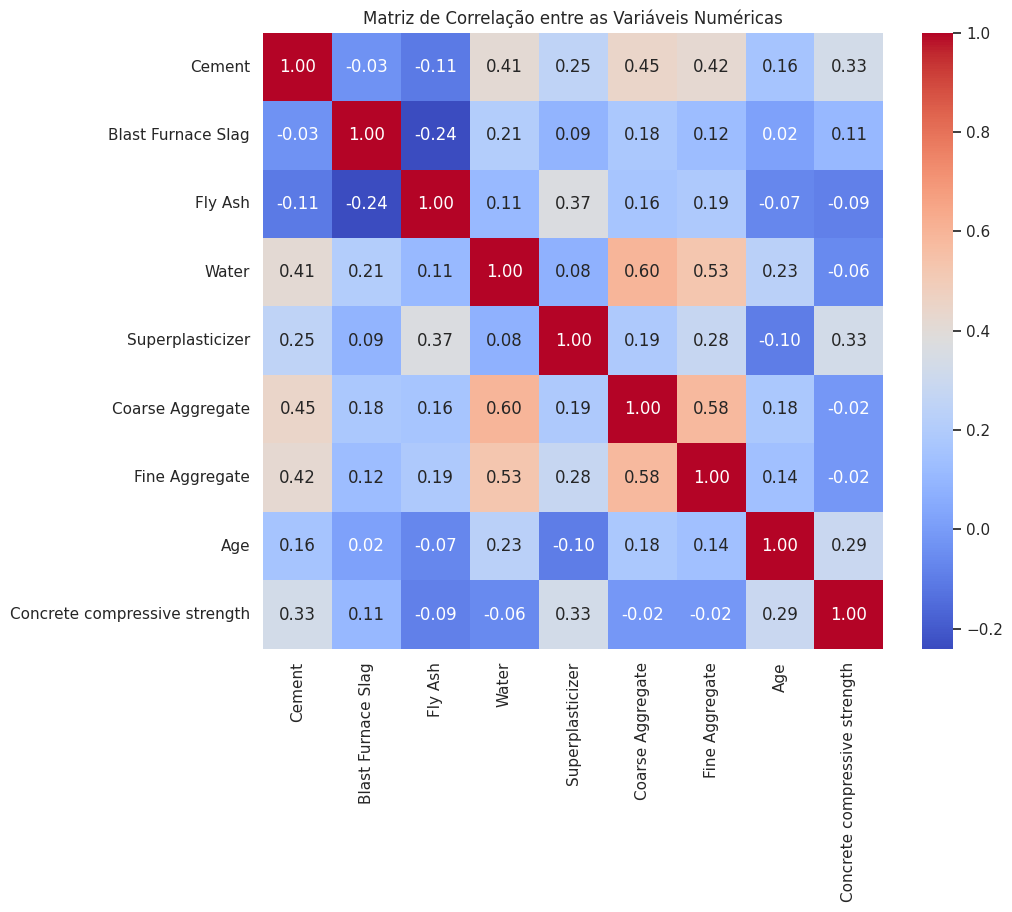

In [ ]:
# 8. Matriz de correlação
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Matriz de Correlação entre as Variáveis Numéricas')
plt.show()

In [ ]:
# Conferir nomes das colunas
print("Colunas do dataset:", df.columns.tolist())

Colunas do dataset: ['Cement', 'Blast Furnace Slag', 'Fly Ash', 'Water', 'Superplasticizer', 'Coarse Aggregate', 'Fine Aggregate', 'Age', 'Concrete compressive strength', 'Strength Category']


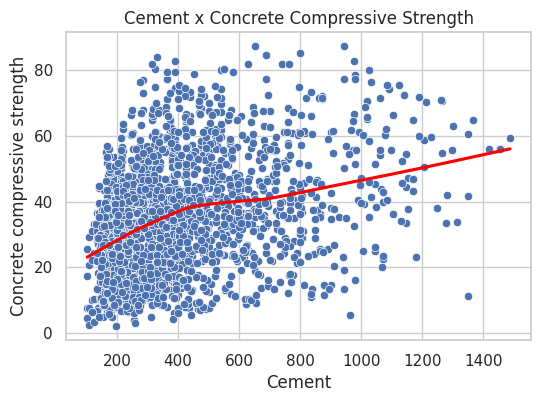

In [ ]:
# 9. Gráfico de dispersão: Cement x Concrete compressive strength
plt.figure(figsize=(6,4))
sns.scatterplot(x='Cement', y='Concrete compressive strength', data=df)
sns.regplot(x='Cement', y='Concrete compressive strength', data=df, scatter=False, lowess=True, color='red')
plt.title('Cement x Concrete Compressive Strength')
plt.show()

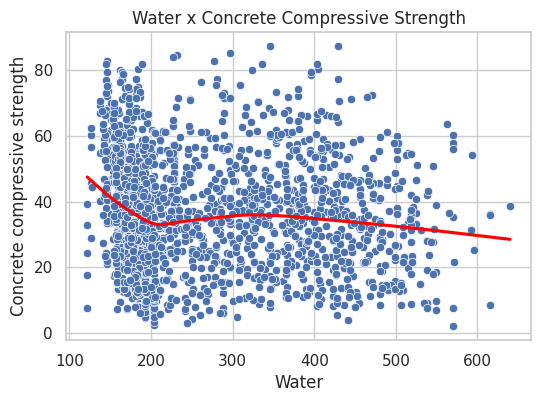

In [ ]:
# 10. Gráfico de dispersão: Water x Concrete compressive strength
plt.figure(figsize=(6,4))
sns.scatterplot(x='Water', y='Concrete compressive strength', data=df)
sns.regplot(x='Water', y='Concrete compressive strength', data=df, scatter=False, lowess=True, color='red')
plt.title('Water x Concrete Compressive Strength')
plt.show()

In [ ]:
# 11. Resistência média do concreto por categoria de força

# Calcular a média de resistência por categoria
mean_strength = df.groupby('Strength Category')['Concrete compressive strength'].mean().reset_index()

print("Resistência média por categoria de força:")
print(mean_strength)

Resistência média por categoria de força:
  Strength Category  Concrete compressive strength
0               Low                      17.905334
1            Medium                      34.701096
2              High                      55.085670


/tmp/ipython-input-3261364505.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_strength = df.groupby('Strength Category')['Concrete compressive strength'].mean().reset_index()


/tmp/ipython-input-1476685853.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


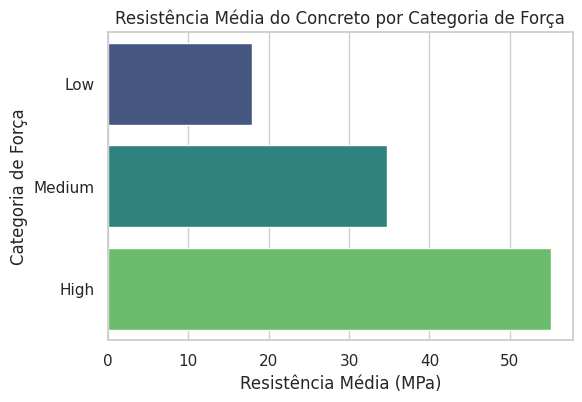

In [ ]:
# Gráfico de barras horizontais
plt.figure(figsize=(6,4))
sns.barplot(
    y='Strength Category',
    x='Concrete compressive strength',
    data=mean_strength,
    palette='viridis'
)
plt.title('Resistência Média do Concreto por Categoria de Força')
plt.xlabel('Resistência Média (MPa)')
plt.ylabel('Categoria de Força')
plt.show()

In [ ]:
# 13. Codificar variáveis categóricas (One-Hot Encoding)
df_encoded = pd.get_dummies(df, columns=['Strength Category'], drop_first=True)

print("\n✅ Variáveis categóricas codificadas com sucesso!")
print("Novas colunas criadas:")
print([col for col in df_encoded.columns if 'Strength Category' in col])

# Conferir o novo formato do dataset
print("Dimensões do novo DataFrame:", df_encoded.shape)


✅ Variáveis categóricas codificadas com sucesso!
Novas colunas criadas:
['Strength Category_Medium', 'Strength Category_High']
Dimensões do novo DataFrame: (2029, 11)


In [ ]:
# 14. Tratamento de valores ausentes

# Verificar valores nulos no dataset codificado
missing_values = df_encoded.isnull().sum()

# Exibir apenas as colunas que possuem valores ausentes
print("🔎 Verificando valores ausentes:\n")
print(missing_values[missing_values > 0])

# Condicional para tratamento automático
if missing_values.sum() == 0:
    print("\n✅ O dataset não possui valores ausentes. Nenhum tratamento necessário.")
else:
    # Preencher valores nulos com a média das colunas numéricas
    df_encoded.fillna(df_encoded.mean(numeric_only=True), inplace=True)
    print("\n⚙️ Valores ausentes detectados e tratados com a média das respectivas colunas numéricas.")
    # Reconfirmar se foi tudo preenchido
    print("\nVerificação pós-tratamento:\n", df_encoded.isnull().sum().sum(), "valores nulos restantes.")

🔎 Verificando valores ausentes:

Concrete compressive strength    9
dtype: int64

⚙️ Valores ausentes detectados e tratados com a média das respectivas colunas numéricas.

Verificação pós-tratamento:
 0 valores nulos restantes.


In [ ]:
# ===============================
# ETAPA 03 — CONSTRUÇÃO E AVALIAÇÃO DE MODELOS DE REGRESSÃO
# ===============================

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

# Separar variáveis independentes (X) e dependente (y)
X = df_encoded.drop(columns=['Concrete compressive strength'])
y = df_encoded['Concrete compressive strength']


In [ ]:
# Dividir em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ===============================
# 🔹 MODELO 1 — RANDOM FOREST REGRESSOR
# ===============================
rf_model = RandomForestRegressor(random_state=42, n_estimators=200)
rf_model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [ ]:
# Previsões
y_pred_rf = rf_model.predict(X_test)

# Avaliação
r2_rf = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print("🌲 Random Forest Regressor:")
print(f"R²: {r2_rf:.4f}")
print(f"MAE: {mae_rf:.4f}")

🌲 Random Forest Regressor:
R²: 0.9072
MAE: 3.7030


In [ ]:
# ===============================
# 🔹 MODELO 2 — REGRESSÃO LINEAR
# ===============================
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)



LinearRegression()

In [ ]:
# Previsões
y_pred_lr = lr_model.predict(X_test)

In [ ]:
# Avaliação
r2_lr = r2_score(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)

print("\n📈 Regressão Linear:")
print(f"R²: {r2_lr:.4f}")
print(f"MAE: {mae_lr:.4f}")


📈 Regressão Linear:
R²: 0.8311
MAE: 5.1763


In [ ]:
# 🔍 COMPARAÇÃO ENTRE OS MODELOS
# ===============================
print("\n===============================")
print("📊 COMPARAÇÃO ENTRE MODELOS")
print("===============================")
print(f"Random Forest -> R²: {r2_rf:.4f} | MAE: {mae_rf:.4f}")
print(f"Linear Reg.   -> R²: {r2_lr:.4f} | MAE: {mae_lr:.4f}")




📊 COMPARAÇÃO ENTRE MODELOS
Random Forest -> R²: 0.9072 | MAE: 3.7030
Linear Reg.   -> R²: 0.8311 | MAE: 5.1763


In [ ]:
#Escolher o melhor modelo com base nas métricas
if r2_rf > r2_lr and mae_rf < mae_lr:
    print("\n✅ O modelo Random Forest apresentou melhor desempenho (maior R² e menor MAE).")
elif r2_lr > r2_rf and mae_lr < mae_rf:
    print("\n✅ O modelo de Regressão Linear apresentou melhor desempenho.")
else:
    print("\n⚖️ Ambos os modelos apresentaram desempenhos semelhantes.")


✅ O modelo Random Forest apresentou melhor desempenho (maior R² e menor MAE).


In [ ]:
# ===============================
# 🌿 Interpretação rápida dos resultados
# ===============================
print("\n📌 Interpretação:")
print("""
• O R² (coeficiente de determinação) indica o quanto das variações na resistência do concreto
  são explicadas pelo modelo. Valores mais próximos de 1 indicam melhor ajuste.

• O MAE (Erro Absoluto Médio) mostra, em média, o quanto o modelo erra na previsão
  da resistência do concreto em unidades da variável-alvo.

• A comparação entre Random Forest e Regressão Linear mostra qual modelo é mais robusto
  para capturar relações não lineares entre as variáveis (como cimento, água e agregados).
""")


📌 Interpretação:

• O R² (coeficiente de determinação) indica o quanto das variações na resistência do concreto 
  são explicadas pelo modelo. Valores mais próximos de 1 indicam melhor ajuste.

• O MAE (Erro Absoluto Médio) mostra, em média, o quanto o modelo erra na previsão 
  da resistência do concreto em unidades da variável-alvo.

• A comparação entre Random Forest e Regressão Linear mostra qual modelo é mais robusto
  para capturar relações não lineares entre as variáveis (como cimento, água e agregados).



In [ ]:
# ===============================
# ETAPA 04 — PREDIZENDO UM RESULTADO
# ===============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Análise da importância das variáveis (usando o modelo Random Forest)
importances = pd.DataFrame({
    'Variável': X.columns,
    'Importância': rf_model.feature_importances_
}).sort_values(by='Importância', ascending=False)

print("📊 Importância das variáveis no modelo Random Forest:\n")
print(importances)

📊 Importância das variáveis no modelo Random Forest:

                   Variável  Importância
9    Strength Category_High     0.646769
8  Strength Category_Medium     0.159137
7                       Age     0.036820
0                    Cement     0.029872
3                     Water     0.026354
4          Superplasticizer     0.024763
1        Blast Furnace Slag     0.021647
5          Coarse Aggregate     0.020391
6            Fine Aggregate     0.018819
2                   Fly Ash     0.015428


/tmp/ipython-input-3774467364.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importância', y='Variável', data=importances, palette='viridis')


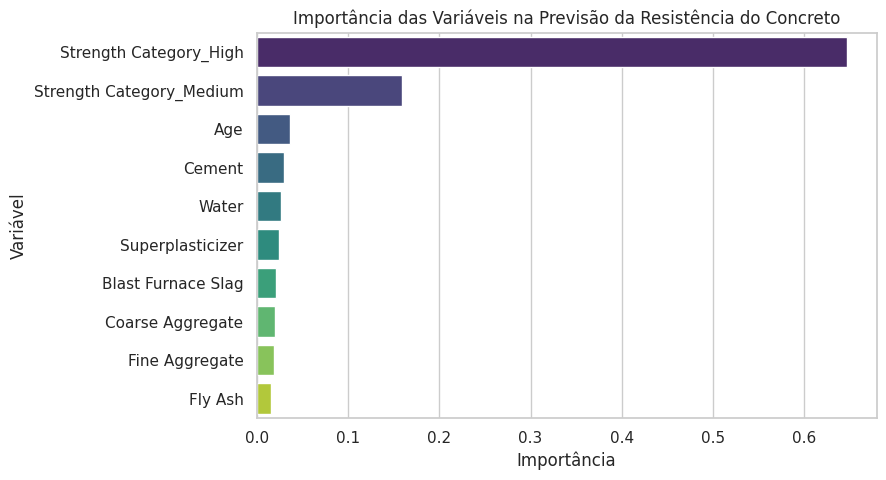

In [ ]:
# Gráfico da importância das variáveis
plt.figure(figsize=(8,5))
sns.barplot(x='Importância', y='Variável', data=importances, palette='viridis')
plt.title('Importância das Variáveis na Previsão da Resistência do Concreto')
plt.show()


In [ ]:
# Criar um novo exemplo para prever
novo_concreto = pd.DataFrame({
    'Cement': [550],
    'Blast Furnace Slag': [150],
    'Fly Ash': [0],
    'Water': [180],
    'Superplasticizer': [2.5],
    'Coarse Aggregate': [1000],
    'Fine Aggregate': [700],
    'Age': [25]
})

# ⚙️ Verificar se o dataset original tinha variáveis dummies
# (ex: Strength Category codificada)
for col in X.columns:
    if col not in novo_concreto.columns:
        novo_concreto[col] = 0  # adiciona colunas faltantes com 0

In [ ]:
# Fazer a previsão com o modelo Random Forest
predicao_rf = rf_model.predict(novo_concreto)[0]

print(f"\n🧠 Previsão da resistência do concreto (Random Forest): {predicao_rf:.2f} MPa")



🧠 Previsão da resistência do concreto (Random Forest): 25.04 MPa


In [ ]:
# Fazer a previsão com o modelo Linear (opcional, para comparar)
predicao_lr = lr_model.predict(novo_concreto)[0]
print(f"📈 Previsão da resistência do concreto (Regressão Linear): {predicao_lr:.2f} MPa")

📈 Previsão da resistência do concreto (Regressão Linear): 21.85 MPa


In [ ]:
# ===============================
# Interpretação do resultado
# ===============================
print("\n📌 Interpretação:")
print(f"""
Com base nos valores informados:
- Cimento alto (550) e baixo teor de água (180) tendem a aumentar a resistência do concreto.
- Superplastificante presente em pequena quantidade (2.5) ajuda na trabalhabilidade sem reduzir a resistência.
- A idade (25 dias) indica que o concreto já passou pelo período inicial de cura, aproximando-se da resistência final.

✅ A previsão indica que o concreto deve ter uma resistência aproximada de {predicao_rf:.2f} MPa segundo o modelo Random Forest,
e {predicao_lr:.2f} MPa segundo o modelo Linear.
""")


📌 Interpretação:

Com base nos valores informados:
- Cimento alto (550) e baixo teor de água (180) tendem a aumentar a resistência do concreto.
- Superplastificante presente em pequena quantidade (2.5) ajuda na trabalhabilidade sem reduzir a resistência.
- A idade (25 dias) indica que o concreto já passou pelo período inicial de cura, aproximando-se da resistência final.

✅ A previsão indica que o concreto deve ter uma resistência aproximada de 25.04 MPa segundo o modelo Random Forest,
e 21.85 MPa segundo o modelo Linear.

